# CHAPTER 3
# NumPy Basics

NumPy, short for Numerical Python, is one of the most important foundational packages for numerical computing in Python. Most computational packages providing scientific functionality use NumPy’s array objects as the _lingua franca_ for data exchange.

Here are some of the things you’ll find in NumPy: 
<br>
-  ndarray, an efficient multidimensional array providing fast array-oriented arithmetic operations and flexible broadcasting capabilities. 
-  Mathematical functions for fast operations on entire arrays of data without having to write loops. 
-  Tools for reading/writing array data to disk and working with memory-mapped files. 
-  Linear algebra, random number generation, and Fourier transform capabilities. 
-  A C API (Common Application Programming Interface) for connecting NumPy with libraries written in C, C++, or FORTRAN.

While NumPy by itself does not provide modeling or scientific functionality, having an understanding of NumPy arrays and array-oriented computing will help you use tools with array-oriented semantics, like pandas, much more effectively. One of the reasons NumPy is so important for numerical computations in Python is because it is designed for efficiency on large arrays of data. There are a number of reasons for this: 
-  NumPy internally stores data in a contiguous block of memory, independent of other built-in Python objects. NumPy’s library of algorithms written in the C language can operate on this memory without any type checking or other overhead. NumPy arrays also use much less memory than built-in Python sequences. 
- NumPy operations perform complex computations on entire arrays without the need for Python for loops.

To give you an idea of the performance difference, consider a NumPy array of one million integers, and the equivalent Python list:

In [13]:
import numpy as np

my_arr = np.arange(1000000)
my_list = list(range(1000000)) 

Now let’s multiply each sequence by 2:

In [26]:
%time for _ in range(10): my_arr2 = my_arr * 2 

CPU times: total: 15.6 ms
Wall time: 27.1 ms


In [25]:
%time for _ in range(10): my_list2 = [x * 2 for x in my_list] 

CPU times: total: 1.16 s
Wall time: 1.23 s


NumPy-based algorithms are generally 10 to 100 times faster (or more) than their pure Python counterparts and use significantly less memory. 

Explanation
`%time`:

This is a "magic command" in Jupyter Notebooks (and IPython environments). The `%time` command measures and outputs the time taken to execute a single line of code.
Using `%time` before a line of code will display how long it took to execute that code once.

`for _ in range(10)`:

This is a for loop that iterates 10 times.
The underscore _ is often used as a placeholder when the loop variable isn't used in the body of the loop. Here, it indicates that we don’t care about the loop variable, only that the loop runs 10 times.

`my_arr2 = my_arr * 2`:

Inside the loop, the code multiplies `my_arr` by 2 and assigns the result to `my_arr2`.
If `my_arr` is a list, then `my_arr * 2` will concatenate the list with itself, essentially doubling its length. For example, if `my_arr = [1, 2, 3]`, then `my_arr * 2` will result in `[1, 2, 3, 1, 2, 3]`.

If `my_arr` is a NumPy array, `my_arr * 2` will multiply each element in the array by 2.

Putting It All Together:

The `%time` command will measure the time taken to run the loop (where `my_arr * 2` is performed) 10 times.
After the code completes, the `%time` magic command will print the total time taken for all 10 iterations combined.

For more detail time information, use `%timeit`

## 3.1  The NumPy ndarray: A Multidimensional Array Object 

One of the key features of NumPy is its N-dimensional array object, or ndarray, which is a fast, flexible container for large datasets in Python. Arrays enable you to perform mathematical operations on whole blocks of data using similar syntax to the equivalent operations between scalar elements. To give you a flavor of how NumPy enables batch computations with similar syntax to scalar values on built-in Python objects, first import NumPy and generate a small array of random data:


In [41]:
import numpy as np

# Generate some random data
data = np.random.randn(2, 3)
data

array([[-0.43926105,  0.39069075, -1.40265903],
       [-0.06907451,  2.15059065,  1.60945562]])

Code explanation:\
`np.random.randn(2, 3)`: This generates a 2x3 array (2 rows and 3 columns) of random numbers.

`np.random.randn()` generates numbers from a normal distribution with a mean of 0 and a standard deviation of 1.\
The arguments (2, 3) specify the shape of the array, meaning it will have 2 rows and 3 columns.

Then write mathematical operations with data:

In [43]:
data * 10

array([[ -4.3926105 ,   3.90690749, -14.02659028],
       [ -0.69074506,  21.50590655,  16.09455621]])

In [45]:
data + data

array([[-0.8785221 ,  0.7813815 , -2.80531806],
       [-0.13814901,  4.30118131,  3.21891124]])

In the first example, all of the elements have been multiplied by 10. In the second, the corresponding values in each “cell” in the array have been added to each other.

An ndarray is a generic multidimensional container for homogeneous data; that is, all of the elements must be the same type. Every array has a shape, a tuple indicating the size of each dimension, and a dtype, an object describing the data type of the array:

In [47]:
data.shape

(2, 3)

In [49]:
data.dtype

dtype('float64')

### 3.1.1 Creating ndarrays 

The easiest way to create an array is to use the array function. This accepts any sequence-like object (including other arrays) and produces a new NumPy array containing the passed data. For example, a list is a good candidate for conversion:


In [51]:
data1 = [6, 7.5, 8, 0, 1]
arr1 = np.array(data1)
arr1

array([6. , 7.5, 8. , 0. , 1. ])

Nested sequences, like a list of equal-length lists, will be converted into a multidimensional array:

Since _data2_ was a list of lists, the NumPy array _arr2_ has two dimensions with shape inferred from the data. We can confirm this by inspecting the **ndim** and **shape** attributes:

In [53]:
data2 = [[1, 2, 3,4], [5, 6, 7, 8]]
arr2 = np.array(data2)
arr2 

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [61]:
score=[[4.0,4.0],[3.8,3.65],[3.76,3.69]]
    score_arr=np.array(score)
score_arr

IndentationError: unexpected indent (2240797980.py, line 2)

In [57]:
arr2.ndim 

2

In [59]:
arr2.shape

(2, 4)

Unless explicitly specified (more on this later), np.array tries to infer a good data type for the array that it creates. The data type is stored in a special **dtype** metadata object; for example, in the previous two examples we have:

In [63]:
print(arr1.dtype)
print(arr2.dtype)

float64
int32


In addition to np.array, there are a number of other functions for creating new arrays. As examples, **zeros** and **ones** create arrays of 0s or 1s, respectively, with a given length or shape. **empty** creates an array without initializing its values to any particular value. To create a higher dimensional array with these methods, pass a tuple for the shape:

In [65]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

In [67]:
np.zeros((3,6))

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [69]:
np.empty((2,2,3))

array([[[8.86286947e-312, 3.16202013e-322, 0.00000000e+000],
        [0.00000000e+000, 1.16709769e-312, 8.01204669e+165]],

       [[1.26775087e-071, 2.58216579e-057, 3.34792420e-061],
        [1.53155097e-047, 5.78347054e+174, 4.95894607e-062]]])

It’s not safe to assume that np.empty will return an array of all zeros. In some cases, it may return uninitialized “garbage” values.


**arange** is an array-valued version of the built-in Python range function:


In [42]:
np.arange(15)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [71]:
np.ones(5)

array([1., 1., 1., 1., 1.])

In [46]:
np.full((2,3),6)

array([[6, 6, 6],
       [6, 6, 6]])

In [52]:
np.eye(5,5)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

See Table 3-1 for a short list of standard array creation functions. Since NumPy is focused on numerical computing, the data type, if not specified, will in many cases be float64 (floating point).

<br>
<center>Table 3.1: Array creation functions </center>
<img src="Table3.1.jpg", style="width: 800px";>

#### 3.1.1.1 Data Types for ndarrays 

The data type or **dtype** is a special object containing the information (or metadata, data about data) the ndarray needs to interpret a chunk of memory as a particular type of data:


In [73]:
arr1 = np.array([1, 2, 3], dtype=np.float64)
arr2 = np.array([1, 2, 3], dtype=np.int32)

print(arr1.dtype)
print(arr2.dtype)

float64
int32


**dtypes** are a source of NumPy’s flexibility for interacting with data coming from other systems. In most cases they provide a mapping directly onto an underlying disk or memory representation, which makes it easy to read and write binary streams of data to disk and also to connect to code written in a low-level language like C or Fortran. The numerical dtypes are named the same way: a type name, like float or int, followed by a number indicating the number of bits per element. A standard doubleprecision floating-point value (what’s used under the hood in Python’s float object) takes up 8 bytes or 64 bits. Thus, this type is known in NumPy as float64. 

You can explicitly convert or *cast* an array from one dtype to another using ndarray’s **astype** method.

In [56]:
arr = np.array([1, 2, 3, 4, 5])
arr.dtype

dtype('int32')

In [23]:
float_arr = arr.astype(np.float64)
float_arr.dtype

dtype('float64')

In [24]:
arr.dtype

dtype('int32')

In the above example, integers were cast to floating point. If we cast some floating-point numbers to be of integer dtype, the decimal part will be truncated:

In [62]:
arr = np.array([3.7, -1.2, -2.6, 0.5, 12.9, 10.1])
arr 

array([ 3.7, -1.2, -2.6,  0.5, 12.9, 10.1])

In [60]:
arr.astype(np.int32) 

array([ 3, -1, -2,  0, 12, 10])

If you have an array of strings representing numbers, you can use **astype** to convert them to numeric form:

In [27]:
numeric_strings = np.array(['1.25', '-9.6', '42'], dtype=np.string_)
numeric_strings.astype(float)

array([ 1.25, -9.6 , 42.  ])

In [16]:
import numpy as np
#create a numpy array that stores the following carry marks,
#quiz 1=12/15,quiz 2=10/15 quiz 3=11.5/15
#convert all the quiz marks to be 5% each and store in second np array
carry_marks = np.array([12, 10, 11.5])

# Step 2: Convert each quiz mark to a 5% scale
# Each quiz is originally out of 15 marks
# So, (score / 15) * 5 gives the new 5% scaled mark
scaled_marks = (carry_marks / 15) * 5

# Display the results
print("Original carry marks:", carry_marks)
print("Scaled marks (5% each):", scaled_marks)



Original carry marks: [12.  10.  11.5]
Scaled marks (5% each): [4.         3.33333333 3.83333333]


### 3.1.2 Arithmetic with NumPy Arrays 

Arrays are important because they enable you to express batch operations on data without writing any **for** loops. NumPy users call this *vectorization*. Any arithmetic operations between equal-size arrays applies the operation element-wise:


In [18]:
arr = np.array([[1., 2., 3.], [4., 5., 6.]])
arr

array([[1., 2., 3.],
       [4., 5., 6.]])

In [70]:
arr * arr

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [68]:
arr - arr

array([[0., 0., 0.],
       [0., 0., 0.]])

Arithmetic operations with scalars propagate the scalar argument to each element in the array:

In [31]:
1 / arr

array([[1.        , 0.5       , 0.33333333],
       [0.25      , 0.2       , 0.16666667]])

In [32]:
arr ** 0.5

array([[1.        , 1.41421356, 1.73205081],
       [2.        , 2.23606798, 2.44948974]])

Comparisons between arrays of the same size yield boolean arrays:

In [33]:
arr

array([[1., 2., 3.],
       [4., 5., 6.]])

In [34]:
arr2 = np.array([[0., 4., 1.], [7., 2., 12.]])
arr2 

array([[ 0.,  4.,  1.],
       [ 7.,  2., 12.]])

In [35]:
 arr2 > arr

array([[False,  True, False],
       [ True, False,  True]])

### 3.1.3 Basic Indexing and Slicing 

NumPy array indexing is a rich topic, as there are many ways you may want to select a subset of your data or individual elements. One-dimensional arrays are simple; on the surface they act similarly to Python lists:

In [77]:
arr = np.arange(10)
arr

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [79]:
arr[5]

5

In [81]:
arr[5:8]

array([5, 6, 7])

In [97]:
arr[5:8] = 12
arr

array([ 0,  1,  2,  3,  4, 12, 12, 12,  8,  9])

As you can see, if you assign a scalar value to a slice, as in arr[5:8] = 12, the value is propagated (or broadcasted henceforth) to the entire selection. An important first distinction from Python’s built-in lists is that array slices are views on the original array. This means that the data is not copied, and any modifications to the view will be reflected in the source array. 

To give an example of this, we first create a slice of arr:


In [99]:
arr_slice = arr[5:8]
arr_slice 

array([12, 12, 12])

Now, when we change values in arr_slice, the mutations are reflected in the original array arr:

In [103]:
arr_slice[1] = 12345
#arr_slice 
arr

array([    0,     1,     2,     3,     4,    12, 12345,    12,     8,
           9])

The “bare” slice [ : ] will assign to all values in an array:

In [105]:
arr_slice[:] = 64
arr 

array([ 0,  1,  2,  3,  4, 64, 64, 64,  8,  9])

With higher dimensional arrays, you have many more options. In a two-dimensional array, the elements at each index are no longer scalars but rather one-dimensional arrays:

In [117]:
arr2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(arr2d)
#print(arr2d.shape)
arr2d[2] 

[[1 2 3]
 [4 5 6]
 [7 8 9]]


array([7, 8, 9])

Thus, individual elements can be accessed recursively. But that is a bit too much work, so you can pass a comma-separated list of indices to select individual elements. So these are equivalent:

In [119]:
arr2d[0][2] 

3

In [113]:
arr2d[0, 2]

3

See Figure 3-1 for an illustration of indexing on a two-dimensional array. We find it helpful to think of axis 0 as the “rows” of the array and axis 1 as the “columns.”

<img src="Figure3.1.jpg", style="width: 500px";>
<center>Figure 3.1: Indexing elements in a NumPy array </center>
<br>

In multidimensional arrays, if you omit later indices, the returned object will be a lower dimensional ndarray consisting of all the data along the higher dimensions. So in the 2 × 2 × 3 array arr3d:

In [121]:
arr3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
arr3d 

array([[[ 1,  2,  3],
        [ 4,  5,  6]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

arr3d[0] is a 2 × 3 array:

In [127]:
arr3d[0]

array([[42, 42, 42],
       [42, 42, 42]])

Both scalar values and arrays can be assigned to arr3d[0]:

In [129]:
old_values = arr3d[0].copy()
arr3d[0] = 42
arr3d 

array([[[42, 42, 42],
        [42, 42, 42]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

In [131]:
arr3d[0] = old_values
arr3d

array([[[42, 42, 42],
        [42, 42, 42]],

       [[ 7,  8,  9],
        [10, 11, 12]]])

Similarly, arr3d[1, 0] gives you all of the values whose indices start with (1, 0), forming a 1-dimensional array:

In [139]:
 arr3d[1, 0]

array([7, 8, 9])

In [141]:
arr3d[0,1,2]=1
arr3d[0,:,2]

array([42,  1])

In [143]:
arr3d[1,1,1]

11

In [145]:
arr3d[1,0,0:2]

array([7, 8])

In [54]:
arr3d[1,1,-2:-1]

array([11])

This expression is the same as though we had indexed in two steps:

In [149]:
x = arr3d[1]
x 

array([[ 7,  8,  9],
       [10, 11, 12]])

In [104]:
arr3d[0,1,0]

4

In [153]:
x[0]

array([7, 8, 9])

In [155]:
x

array([[ 7,  8,  9],
       [10, 11, 12]])

Note that in all of these cases where subsections of the array have been selected, the returned arrays are views.

#### 3.1.3.1 Indexing with slices

Like one-dimensional objects such as Python lists, ndarrays can be sliced with the familiar syntax:

In [157]:
print(arr)

arr[1:6]

[ 0  1  2  3  4 64 64 64  8  9]


array([ 1,  2,  3,  4, 64])

Consider the two-dimensional array from before, arr2d. Slicing this array is a bit different:

In [159]:
print(arr2d)

arr2d[:2]

[[1 2 3]
 [4 5 6]
 [7 8 9]]


array([[1, 2, 3],
       [4, 5, 6]])

As you can see, it has sliced along axis 0, the first axis. A slice, therefore, selects a range of elements along an axis. It can be helpful to read the expression arr2d[:2] as “select the first two rows of arr2d.” 

You can pass multiple slices just like you can pass multiple indexes:

In [122]:
arr2d
arr2d[:2, 1:] 

array([[2, 3],
       [5, 6]])

When slicing like this, you always obtain array views of the same number of dimensions. By mixing integer indexes and slices, you get lower dimensional slices. 

For example, you can select the second row but only the first two columns like so:

In [118]:
 arr2d[1, :2]

array([4, 5])

Similarly, you can select the third column but only the first two rows like so:

In [124]:
print(arr2d) 
arr2d[:2, 2] 

[[1 2 3]
 [4 5 6]
 [7 8 9]]


array([3, 6])

See Figure 3-2 for an illustration. Note that a colon by itself means to take the entire axis, so you can slice only higher dimensional axes by doing:

In [60]:
 arr2d[:, :1] 

array([[1],
       [4],
       [7]])

Of course, assigning to a slice expression assigns to the whole selection:

In [126]:
arr2d[:2, 1:] = 0
arr2d 

array([[1, 0, 0],
       [4, 0, 0],
       [7, 8, 9]])

<img src="Figure3.2.jpg", style="width: 500px";>
<center>Figure 3.2: Two-dimensional array slicing  </center>
<br>


### 3.1.4Transposing Arrays and Swapping Axes 

Transposing is a special form of reshaping that similarly returns a view on the underlying data without copying anything. Arrays have the transpose method and also the special **T** attribute:


In [15]:
arr = np.arange(15).reshape((3, 5))
arr

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [60]:
arr.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

When doing matrix computations, you may do this very often—for example, when computing the inner matrix product using **np.dot**:
The np.dot function in NumPy is used for dot product operations. The dot product is a mathematical operation that depends on the types and dimensions of the arrays involved.

In [17]:
arr = np.random.randn(6, 3)
arr 

array([[-1.17540393, -0.5360027 , -1.05921736],
       [ 0.84152465, -0.36382305, -0.13569083],
       [-1.1271368 ,  1.71387505, -1.07227121],
       [-0.56993442, -0.43217964,  0.15153398],
       [ 0.13674389, -0.38648736,  0.38303572],
       [ 1.04224833,  0.85388357, -1.51586385]])

In [19]:
np.dot(arr.T, arr)

array([[ 4.78998124, -0.52449501,  0.72552421],
       [-0.52449501,  4.42230267, -2.72852764],
       [ 0.72552421, -2.72852764,  4.75764106]])

For higher dimensional arrays, **transpose** will accept a tuple of axis numbers to permute the axes (for extra mind bending):

In [21]:
arr = np.arange(16).reshape((2, 2, 4))
arr 

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7]],

       [[ 8,  9, 10, 11],
        [12, 13, 14, 15]]])

In [45]:
arr.transpose((1, 2, 0)) 

array([[[ 0,  8],
        [ 1,  9],
        [ 2, 10],
        [ 3, 11]],

       [[ 4, 12],
        [ 5, 13],
        [ 6, 14],
        [ 7, 15]]])

In [193]:
arrt=np.arange(24).reshape(2,3,4)
arrt

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [197]:
arrt.transpose(1,0,2)

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

Here, the axes have been reordered with the second axis first, the first axis second, and the last axis unchanged. 

What `transpose((1, 0, 2))` Does\
When you call `arr.transpose((1, 0, 2))`, you’re telling NumPy to:

Take Axis 1 from the original array and make it Axis 0 in the transposed array.
Take Axis 0 from the original array and make it Axis 1 in the transposed array.
Leave Axis 2 in its original position.
In simpler terms, axes 0 and 1 are swapped, and axis 2 stays the same.

In a 3D array, you typically have three axes:

Axis 0 (often represents rows or depth)
Axis 1 (often represents columns or height)
Axis 2 (often represents depth or width, depending on the data structure)

Simple transposing with **.T** is a special case of swapping axes. ndarray has the method **swapaxes**, which takes a pair of axis numbers and switches the indicated axes to rearrange the data:

In [94]:
arr
#2 2 4

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7]],

       [[ 8,  9, 10, 11],
        [12, 13, 14, 15]]])

In [108]:
arr.swapaxes(1, 2) 
#2 4 2

array([[[ 0,  4],
        [ 1,  5],
        [ 2,  6],
        [ 3,  7]],

       [[ 8, 12],
        [ 9, 13],
        [10, 14],
        [11, 15]]])

In [205]:
arr.swapaxes(2,0)
#4 2 2

array([[[ 0,  8],
        [ 4, 12]],

       [[ 1,  9],
        [ 5, 13]],

       [[ 2, 10],
        [ 6, 14]],

       [[ 3, 11],
        [ 7, 15]]])

swapaxes similarly returns a view on the data without making a copy. 

## 3.2 Universal Functions 

A universal function, or **ufunc**, is a function that performs element-wise operations on data in ndarrays. Many ufuncs are simple element-wise transformations, like **sqrt** or **exp**:


In [49]:
import numpy as np

arr = np.arange(10)
arr 

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [51]:
 np.sqrt(arr) 

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

In [53]:
 np.exp(arr)
#exponential

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

These are referred to as *unary ufuncs*. Others, such as add or maximum, take two arrays (thus, binary ufuncs) and return a single array as the result:

In [55]:
x = np.random.randn(8)
y = np.random.randn(8)

print(x)
print()
print(y)

[-0.67158388  0.43293236 -1.56738336  0.12509359  1.15181991 -0.65969453
 -0.12727559 -2.2766944 ]

[-0.91215289  0.1294763   0.32930016  0.90706108  0.02139559  0.13852201
  0.74112306 -1.11411963]


In [57]:
np.maximum(x, y) 

array([-0.67158388,  0.43293236,  0.32930016,  0.90706108,  1.15181991,
        0.13852201,  0.74112306, -1.11411963])

Here, **numpy.maximum** computed the element-wise maximum of the elements in *x* and *y*. 

While not common, a ufunc can return multiple arrays. **modf** is one example, a vectorized version of the built-in Python **divmod**; it returns the fractional and integral parts of a floating-point array:


In [65]:
arr = np.random.randn(7) * 5
arr 

array([-5.86240459, -7.19882805, -1.82952589,  2.27649369, -2.67859409,
       -0.86956804, -3.86826745])

In [67]:
remainder, whole_part = np.modf(arr)
#splits each element of an array into its fractional and integer parts
remainder 

array([-0.86240459, -0.19882805, -0.82952589,  0.27649369, -0.67859409,
       -0.86956804, -0.86826745])

In [69]:
whole_part

array([-5., -7., -1.,  2., -2., -0., -3.])

Ufuncs accept an optional out argument that allows them to operate in-place on arrays:

In [71]:
arr

array([-5.86240459, -7.19882805, -1.82952589,  2.27649369, -2.67859409,
       -0.86956804, -3.86826745])

In [73]:
np.sqrt(arr)

C:\Users\jingy\AppData\Local\Temp\ipykernel_2684\2296558006.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr)


array([       nan,        nan,        nan, 1.50880538,        nan,
              nan,        nan])

In [75]:
arr

array([-5.86240459, -7.19882805, -1.82952589,  2.27649369, -2.67859409,
       -0.86956804, -3.86826745])

In [77]:
np.sqrt(arr, arr)

C:\Users\jingy\AppData\Local\Temp\ipykernel_2684\269955669.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(arr, arr)


array([       nan,        nan,        nan, 1.50880538,        nan,
              nan,        nan])

In [82]:
arr

array([0.53621511, 0.76686178, 0.49007756, 2.6844647 , 1.30522457,
              nan, 0.94648803])

See Tables 3-3 and 3-4 for a listing of available ufuncs.

<br>
<center>Table 3.2: Unary *ufuncs*  </center>
<img src="Table3.2.jpg", style="width: 800px";>

<br>
<center>Table 3.3: Binary *ufuncs*  </center>
<img src="Table3.3.jpg", style="width: 800px";>


## 3.3 Array-Oriented Programming with Arrays 

Using NumPy arrays enables you to express many kinds of data processing tasks as concise array expressions that might otherwise require writing loops. This practice of replacing explicit loops with array expressions is commonly referred to as *vectorization*. In general, vectorized array operations will often be one or two (or more) orders of magnitude faster than their pure Python equivalents, with the biggest impact in any kind of numerical computations. 

As a simple example, suppose we wished to evaluate the function *sqrt(x^2 + y^2)* across a regular grid of values. The **np.meshgrid** function takes two 1D arrays and produces two 2D matrices corresponding to all pairs of *(x, y)* in the two arrays:


In [219]:
points = np.arange(-5, 5, 0.01) # 1000 equally spaced points
xs, ys = np.meshgrid(points, points)
ys 

array([[-5.  , -5.  , -5.  , ..., -5.  , -5.  , -5.  ],
       [-4.99, -4.99, -4.99, ..., -4.99, -4.99, -4.99],
       [-4.98, -4.98, -4.98, ..., -4.98, -4.98, -4.98],
       ...,
       [ 4.97,  4.97,  4.97, ...,  4.97,  4.97,  4.97],
       [ 4.98,  4.98,  4.98, ...,  4.98,  4.98,  4.98],
       [ 4.99,  4.99,  4.99, ...,  4.99,  4.99,  4.99]])

In [221]:
xs

array([[-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       ...,
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99],
       [-5.  , -4.99, -4.98, ...,  4.97,  4.98,  4.99]])

Now, evaluating the function is a matter of writing the same expression you would write with two points:

In [225]:
z = np.sqrt(xs ** 2 + ys ** 2)
z 

array([[7.07106781, 7.06400028, 7.05693985, ..., 7.04988652, 7.05693985,
        7.06400028],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       ...,
       [7.04988652, 7.04279774, 7.03571603, ..., 7.0286414 , 7.03571603,
        7.04279774],
       [7.05693985, 7.04985815, 7.04278354, ..., 7.03571603, 7.04278354,
        7.04985815],
       [7.06400028, 7.05692568, 7.04985815, ..., 7.04279774, 7.04985815,
        7.05692568]])

As a preview of Chapter 7 (Plotting and Visualization), we use matplotlib to create visualizations of this twodimensional array. Here we used the matplotlib function imshow to create an image plot from a two-dimensional array of function values.

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jingy\AppData\Local\Temp\ipykernel_40540\4180455801.py:3: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")


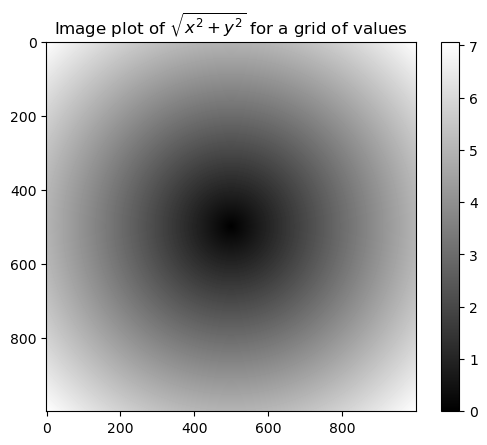

In [227]:
import matplotlib.pyplot as plt

plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values") 
plt.imshow(z, cmap=plt.cm.gray); plt.colorbar() 
plt.show()

### 3.3.1 Expressing Conditional Logic as Array Operations 

The **numpy.where** function is a vectorized version of the ternary expression *x if condition else y*. Suppose we had a boolean array and two arrays of values:


In [229]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])

cond = np.array([True, False, True, True, False]) 

Suppose we wanted to take a value from *xarr* whenever the corresponding value in *cond* is True, and otherwise take the value from *yarr*. A list comprehension doing this might look like:

In [231]:
result = [(x if c else y)for x, y, c in zip(xarr, yarr, cond)]
result

[1.1, 2.2, 1.3, 1.4, 2.5]

This has multiple problems. First, it will not be very fast for large arrays (because all the work is being done in interpreted Python code). Second, it will not work with multidimensional arrays. With **np.where** you can write this very concisely:

In [233]:
result = np.where(cond, xarr, yarr)
result 

array([1.1, 2.2, 1.3, 1.4, 2.5])

The second and third arguments to **np.where** don’t need to be arrays; one or both of them can be scalars. A typical use of where in data analysis is to produce a new array of values based on another array. Suppose you had a matrix of randomly generated data and you wanted to replace all positive values with 2 and all negative values with –2. This is very easy to do with np.where:

In [235]:
arr = np.random.randn(4, 4)
arr 

array([[ 0.7464585 , -1.25024038, -0.54183781, -0.91892447],
       [-0.06267218,  1.11661221, -1.05328458,  1.57591293],
       [ 0.3488957 , -0.25956894,  0.93151786, -0.2242664 ],
       [ 0.25813315, -1.33463598, -1.58884951,  0.81441323]])

In [237]:
arr > 0

array([[ True, False, False, False],
       [False,  True, False,  True],
       [ True, False,  True, False],
       [ True, False, False,  True]])

In [239]:
np.where(arr > 0, 2, -2)

array([[ 2, -2, -2, -2],
       [-2,  2, -2,  2],
       [ 2, -2,  2, -2],
       [ 2, -2, -2,  2]])

You can combine scalars and arrays when using np.where. For example, you can replace all positive values in *arr* with the constant 2 like so:

In [241]:
 np.where(arr > 0, 2, arr) # set only positive values to 2 

array([[ 2.        , -1.25024038, -0.54183781, -0.91892447],
       [-0.06267218,  2.        , -1.05328458,  2.        ],
       [ 2.        , -0.25956894,  2.        , -0.2242664 ],
       [ 2.        , -1.33463598, -1.58884951,  2.        ]])

### 3.3.2 Mathematical and Statistical Methods 

A set of mathematical functions that compute statistics about an entire array or about the data along an axis are accessible as methods of the array class. You can use aggregations (often called reductions) like *sum, mean,* and *std* (standard deviation) either by calling the array instance method or using the top-level NumPy function. Here we generate some normally distributed random data and compute some aggregate statistics:


In [243]:
arr = np.random.randn(5, 4)
arr

array([[-0.6870786 ,  0.05145055, -0.53194926, -0.55327961],
       [ 0.92365091,  0.26940334, -0.19731458, -0.50288756],
       [-0.22223803,  0.89689011,  0.1121904 , -0.17702461],
       [-0.13997459, -0.86203095,  2.43670496, -0.56596367],
       [-0.02815589, -0.43881921, -0.65356498,  1.501565  ]])

In [245]:
arr.mean()

0.03157868507975569

In [247]:
np.mean(arr)

0.03157868507975569

In [249]:
arr.sum()

0.6315737015951138

Functions like **mean** and **sum** take an optional axis argument that computes the statistic over the given axis, resulting in an array with one fewer dimension:

In [255]:
arr

array([[-0.6870786 ,  0.05145055, -0.53194926, -0.55327961],
       [ 0.92365091,  0.26940334, -0.19731458, -0.50288756],
       [-0.22223803,  0.89689011,  0.1121904 , -0.17702461],
       [-0.13997459, -0.86203095,  2.43670496, -0.56596367],
       [-0.02815589, -0.43881921, -0.65356498,  1.501565  ]])

In [257]:
arr.mean(axis=1) 

array([-0.43021423,  0.12321303,  0.15245447,  0.21718393,  0.09525623])

In [79]:
 arr.sum(axis=0) 

nan

Here, *arr.mean(axis=1)* means “compute mean across the columns” where *arr.sum(axis=0)* means “compute sum down the rows.”

Axes are defined for arrays with more than one dimension. A 2-dimensional array has two corresponding axes: the first running vertically downwards across rows (axis 0), and the second running horizontally across columns (axis 1).

Many operation can take place along one of these axes. For example, we can sum each row of an array, in which case we operate along columns, or axis 1:

In [261]:
x = np.arange(12).reshape((3,4))
x

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [101]:
x.sum(axis=0)

array([12, 15, 18, 21])

In [265]:
x.sum(axis=1)

array([ 6, 22, 38])

Other methods like **cumsum** and **cumprod** do not aggregate, instead producing an array of the intermediate results:

In [267]:
arr = np.array([0, 1, 2, 3, 4, 5, 6, 7])
arr.cumsum() 
# calculates the cumulative sum of the elements in an array.

array([ 0,  1,  3,  6, 10, 15, 21, 28])

In multidimensional arrays, accumulation functions like **cumsum** return an array of the same size, but with the partial aggregates computed along the indicated axis according to each lower dimensional slice:

In [269]:
arr = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])
arr 

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [271]:
arr.cumsum(axis=0)
#0+3=3,3+6=9
#1+4=5,5+7=12

array([[ 0,  1,  2],
       [ 3,  5,  7],
       [ 9, 12, 15]])

In [273]:
arr.cumprod(axis=1)
#0x1x2
#3x4x5
#6x7x8

array([[  0,   0,   0],
       [  3,  12,  60],
       [  6,  42, 336]])

See Table 3-4 for a full listing of basic array statistical method.

<br>
<center>Table 3.4: Basic array statistical methods </center>
<img src="Table3.4.jpg", style="width: 800px";>

### 3.3.3 Sorting 

Like Python’s built-in list type, NumPy arrays can be sorted in-place with the sort method:


In [275]:
arr = np.random.randn(6)
arr 

array([ 0.26052196,  0.01199198, -1.02928199, -1.55251194,  0.63815879,
       -0.22269025])

In [277]:
arr.sort()
arr

array([-1.55251194, -1.02928199, -0.22269025,  0.01199198,  0.26052196,
        0.63815879])

You can sort each one-dimensional section of values in a multidimensional array inplace along an axis by passing the axis number to **sort**:

In [279]:
arr = np.random.randn(5, 3)
arr 

array([[ 1.6789112 , -0.664753  ,  0.32034508],
       [ 1.09314061, -0.63859747,  0.60297022],
       [-0.0786382 , -0.40239143, -1.72892666],
       [ 1.84634337, -1.4246007 , -0.99399438],
       [-0.69119645, -0.5564365 , -0.60847952]])

In [281]:
arr.sort(axis=1)
arr 

array([[-0.664753  ,  0.32034508,  1.6789112 ],
       [-0.63859747,  0.60297022,  1.09314061],
       [-1.72892666, -0.40239143, -0.0786382 ],
       [-1.4246007 , -0.99399438,  1.84634337],
       [-0.69119645, -0.60847952, -0.5564365 ]])

The top-level method **np.sort** returns a sorted copy of an array instead of modifying the array in-place. A quick-and-dirty way to compute the quantiles of an array is to sort it and select the value at a particular rank:

In [299]:
large_arr = np.random.randn(1000)
large_arr.sort()
large_arr[int(0.05 * len(large_arr))] # 5% quantile 

-1.6238671478584854